# Lorenz System Analysis (PyTorch SINDy Autoencoder)

This notebook replicates the analysis from Champion et al. (2019) for the Lorenz system using a PyTorch-based SINDy-autoencoder.

### Step 1: Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.integrate import odeint
from autoencoder_torch import full_network
from sindy_utils import sindy_simulate, library_size
import torch

### Step 2: Load Trained Model and Coefficients

In [9]:
# Load model parameters and reconstruct network
timestamp = "2025_05_01_10_33_06_404282"
model_base = f"Results/lorenz_{timestamp}"
params = pickle.load(open(f"{model_base}_params.pkl", 'rb'))

net = full_network(params)
net.load_state_dict(torch.load(f"Results/lorenz_final.pt", map_location='cpu'))
net.eval()

# Extract masked SINDy coefficients
mask = net.coefficient_mask.detach().numpy()
Xi = net.sindy_coefficients.detach().numpy() * mask

print(Xi)

[[  0.          0.         -7.1      ]
 [-10.         -9.6         0.       ]
 [-10.8         0.          0.       ]
 [  0.          0.         -2.6666667]
 [  0.          0.          0.       ]
 [  0.          0.         -3.1      ]
 [  0.         -1.          0.       ]
 [  0.          0.          0.       ]
 [  0.          0.          0.       ]
 [  0.          0.          0.       ]
 [  0.          0.          0.       ]
 [  0.          0.          0.       ]
 [  0.          0.          0.       ]
 [  0.          0.          0.       ]
 [  0.          0.          0.       ]
 [  0.          0.          0.       ]
 [  0.          0.          0.       ]
 [  0.          0.          0.       ]
 [  0.          0.          0.       ]
 [  0.          0.          0.       ]]


### Step 5: Plot Comparison of Latent Dynamics

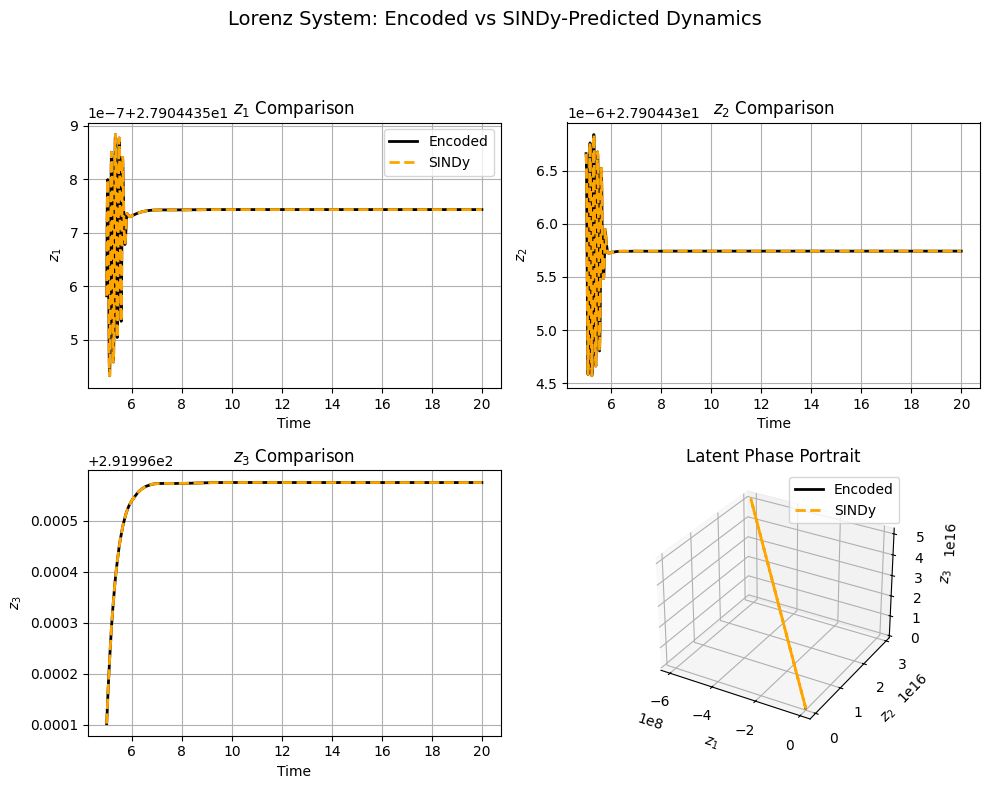

In [11]:
from example_lorenz import generate_lorenz_data
from sindy_utils import sindy_simulate
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Generate test data
t = np.arange(0, 20, 0.01)
z0 = np.array([[-8.0, 7.0, 27.0]])  # single IC
norm = np.array([1, 1, 1])




# Simulate SINDy model from initial encoded latent state
test_data = sindy_simulate(z0[0], t, Xi_true, poly_order=3, include_sine=False)
z_sim = sindy_simulate(z0[0], t, Xi, poly_order=3, include_sine=False)

# Plotting
fig = plt.figure(figsize=(10, 8))
labels = [r"$z_1$", r"$z_2$", r"$z_3$"]
colors = ['tab:blue', 'tab:green', 'tab:red']

# Time series plots
for i in range(3):
    ax = plt.subplot(2, 2, i + 1)
    ax.plot(t[500:], test_data[500:, i], label="Encoded", color='black', linewidth=2)
    ax.plot(t[500:], z_sim[500:, i], '--', label="SINDy", color='orange', linewidth=2)
    ax.set_xlabel("Time")
    ax.set_ylabel(labels[i])
    ax.grid(True)
    ax.set_title(f"{labels[i]} Comparison")
    if i == 0:
        ax.legend()

# 3D attractor
ax3d = fig.add_subplot(2, 2, 4, projection='3d')
ax3d.plot(*test_data.T, label="Encoded", color='black', linewidth=2)
ax3d.plot(*z_sim.T, '--', label="SINDy", color='orange', linewidth=2)
ax3d.set_title("Latent Phase Portrait")
ax3d.set_xlabel("$z_1$")
ax3d.set_ylabel("$z_2$")
ax3d.set_zlabel("$z_3$")
ax3d.legend()

plt.suptitle("Lorenz System: Encoded vs SINDy-Predicted Dynamics", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Step 6: Print Discovered vs. Ground Truth Dynamics

In [3]:
from sindy_utils import library_size

# Construct ground truth coefficient matrix
lib_size = library_size(3, poly_order=3)
Xi_true = np.zeros((lib_size, 3))
Xi_true[1, 0] = -10.0    # -sigma * z1
Xi_true[2, 0] = 10.0     # sigma * z2
Xi_true[1, 1] = -1.0     # -z2
Xi_true[3, 1] = 28.0     # rho * z1
Xi_true[6, 1] = -1.0     # -z1*z3
Xi_true[3, 2] = -8/3     # -beta * z3
Xi_true[5, 2] = 1.0      # z1*z2

# Manually define term names (assuming poly_order = 3 and 3 variables)
terms = [
    "1", "z1", "z2", "z3",
    "z1^2", "z1*z2", "z1*z3", "z2^2", "z2*z3", "z3^2",
    "z1^3", "z1^2*z2", "z1^2*z3", "z1*z2^2", "z1*z2*z3", "z1*z3^2",
    "z2^3", "z2^2*z3", "z2*z3^2", "z3^3"
]

# Print comparison
for i in range(3):
    print(f"\nEquation for dz{i+1}/dt:")
    for j in range(lib_size):
        if abs(Xi[j, i]) > 1e-6 or abs(Xi_true[j, i]) > 1e-6:
            print(f"  Term: {terms[j]:<10} | True: {Xi_true[j, i]: .4f} | Discovered: {Xi[j, i]: .4f}")



Equation for dz1/dt:
  Term: z1         | True: -10.0000 | Discovered: -10.0000
  Term: z2         | True:  10.0000 | Discovered: -10.8000

Equation for dz2/dt:
  Term: z1         | True: -1.0000 | Discovered: -9.6000
  Term: z3         | True:  28.0000 | Discovered:  0.0000
  Term: z1*z3      | True: -1.0000 | Discovered: -1.0000

Equation for dz3/dt:
  Term: 1          | True:  0.0000 | Discovered: -7.1000
  Term: z3         | True: -2.6667 | Discovered: -2.6667
  Term: z1*z2      | True:  1.0000 | Discovered: -3.1000


In [4]:
# Compute summary statistics comparing Xi (discovered) vs Xi_true
nonzero_true = (np.abs(Xi_true) > 1e-6)
nonzero_discovered = (np.abs(Xi) > 1e-6)

# 1. Number of nonzero terms
num_nonzero = np.count_nonzero(Xi)

# 2. Mean absolute error on true nonzero terms
mean_abs_error = np.mean(np.abs(Xi[nonzero_true] - Xi_true[nonzero_true]))

# 3. Exact sparsity match: same pattern of nonzero terms
exact_sparsity_match = np.array_equal(nonzero_discovered, nonzero_true)

# Print summary
print(f"Number of nonzero terms: {num_nonzero}")
print(f"Mean abs. coefficient error: {mean_abs_error:.5f}")
print(f"Exact sparsity match: {exact_sparsity_match}")


Number of nonzero terms: 7
Mean abs. coefficient error: 8.78571
Exact sparsity match: False


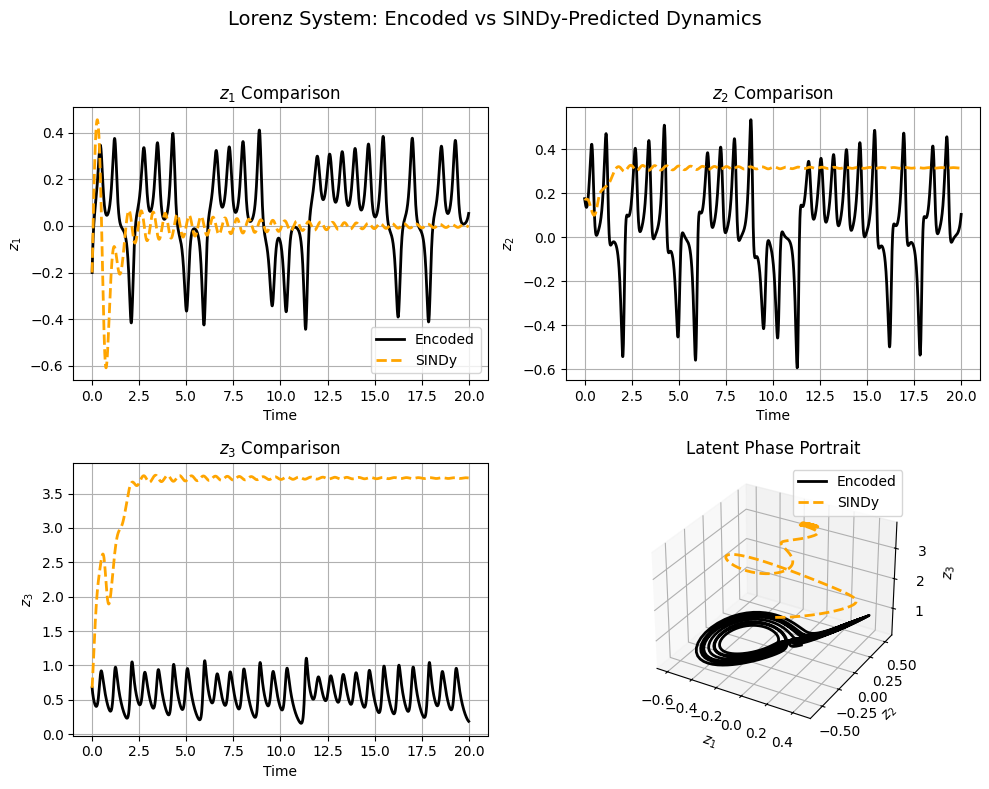